**Lab Exercise 2: Preprocessing the Dataset Using Normalization Techniques**


**Part A: Dataset Understanding**


**Identify the domain of the dataset.**

the domain of the dataset is Finance/Stock Market/CryptoCurrency Prediction..
This is the data of BTC trading from JAN 2017 to DEC 2017


**List all numerical attributes.**

unix: The  timestamp in seconds .

open: The opening price of Bitcoin for that time period .

high: The highest price reached during that time period .

low: The lowest price reached during that time period .

close: The closing price at the end of the time period .

Volume_BTC: The total amount of Bitcoin traded during that interval .

Volume_USD: The total volume traded converted to US Dollars .

Spread: The calculated difference between the high and low price .

MOST OF THEM ARE CONTINUOUS


**List all Categorical attributes.**

symbol: The trading pair, which in your dataset is "BTC/USD" (Nominal).

Day_of_Week: The day the trading occurred, e.g., "Sunday", "Monday" (Ordinal).

Month: The month the trading occurred, e.g., "January", "February" (Nominal/Ordinal).

Is_Weekend: A boolean category indicating if the day is a weekend; True or False (Nominal).

Daily_Trend: The directional movement of the candle, categorized as "Bullish", "Bearish", or "Flat" (Nominal).

Volatility_State: The intensity of the price movement, categorized as "High", "Normal", or "Low" (Ordinal).


**Explain why normalization is required for the selected dataset.**

close price: Values are in the thousands (e.g., 13,000 or 900).

Volume_USD: Values are even larger, sometimes in the tens of thousands (e.g., 20000).

Volume_BTC: Values are extremely small, often single digits or decimals (e.g., 0.59, 1.39, or 7.61).

Spread: Values might be in the tens or hundreds.

values on this scale are too scattered as in 2017 bitcoin had bullish run the values diifer  lot on scale.

**If feed this raw data into machine learning models (like K-Nearest Neighbors, Support Vector Machines, or Neural Networks), the model will assume that larger numbers are mathematically more important.**


**Part B: Data Preparation**

**Load and inspect the dataset.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
ds = pd.read_csv("./BTC-2017min.csv")
ds.sample(5)

#dataset loaded

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
398206,1490872380,2017-03-30 11:13:00,BTC/USD,1036.13,1036.13,1036.12,1036.12,0.271457,281.262110
115388,1507841460,2017-10-12 20:51:00,BTC/USD,5319.67,5319.67,5310.11,5312.23,4.299988,22842.524935
314259,1495909200,2017-05-27 18:20:00,BTC/USD,2131.54,2131.58,2130.67,2130.99,2.850068,6073.465534
258913,1499229960,2017-07-05 04:46:00,BTC/USD,2535.00,2535.00,2535.00,2535.00,7.250000,18378.750000
357840,1493294340,2017-04-27 11:59:00,BTC/USD,1304.90,1304.90,1304.90,1304.90,0.392995,512.819136


In [ ]:
ds.info()
#inspection

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525599 entries, 0 to 525598
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   unix        525599 non-null  int64  
 1   date        525599 non-null  object 
 2   symbol      525599 non-null  object 
 3   open        525599 non-null  float64
 4   high        525599 non-null  float64
 5   low         525599 non-null  float64
 6   close       525599 non-null  float64
 7   Volume BTC  525599 non-null  float64
 8   Volume USD  525599 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 36.1+ MB


In [ ]:
ds.isnull().sum()
# to check null rows for each column in ds

,0
unix,0
date,0
symbol,0
open,0
high,0
low,0
close,0
Volume BTC,0
Volume USD,0


**Handle missing values (if any).**


In [ ]:
ds.isnull().sum().sum()
#to check total null rows in ds but no null rows

np.int64(0)

In [ ]:

if 'unix' in ds.columns:
    ds['date'] = pd.to_datetime(ds['unix'], unit='s')
    ds.set_index('date', inplace=True)


ds['Day_of_Week'] = ds.index.day_name()
ds['Is_Weekend'] = ds.index.dayofweek >= 5
ds['Month'] = ds.index.month_name()


conditions = [
    (ds['close'] > ds['open']),
    (ds['close'] < ds['open'])
]
ds['Daily_Trend'] = np.select(conditions, ['Bullish', 'Bearish'], default='Flat')


ds['Spread'] = ds['high'] - ds['low']
q25 = ds['Spread'].quantile(0.25)
q75 = ds['Spread'].quantile(0.75)
ds['Volatility_State'] = np.select(
    [(ds['Spread'] > q75), (ds['Spread'] < q25)],
    ['High', 'Low'],
    default='Normal'
)


print(ds.head())

#adding new categorical rows(ai generated)

                           unix   symbol    open    high     low   close  Volume_BTC   Volume_USD Day_of_Week  Is_Weekend    Month Daily_Trend  Spread Volatility_State
date                                                                                                                                                                   
2017-01-01 00:01:00  1483228860  BTC/USD  966.34  966.34  966.34  966.34    7.610000  7353.847400      Sunday        True  January        Flat    0.00              Low
2017-01-01 00:02:00  1483228920  BTC/USD  966.16  966.37  966.16  966.37    8.087376  7815.397864      Sunday        True  January     Bullish    0.21           Normal
2017-01-01 00:03:00  1483228980  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday        True  January        Flat    0.00              Low
2017-01-01 00:04:00  1483229040  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday        True  January        Flat    0.00          

In [ ]:
ds.tail()

,unix,date,symbol,open,high,low,close,Volume_BTC,Volume_USD
525594,1483229100,2017-01-01 00:05:00,BTC/USD,966.43,966.43,966.43,966.43,0.107000,103.408010
525595,1483229040,2017-01-01 00:04:00,BTC/USD,966.37,966.37,966.37,966.37,0.000000,0.000000
525596,1483228980,2017-01-01 00:03:00,BTC/USD,966.37,966.37,966.37,966.37,0.000000,0.000000
525597,1483228920,2017-01-01 00:02:00,BTC/USD,966.16,966.37,966.16,966.37,8.087376,7815.397864
525598,1483228860,2017-01-01 00:01:00,BTC/USD,966.34,966.34,966.34,966.34,7.610000,7353.847400


In [ ]:
ds.head()

,unix,symbol,open,high,low,close,Volume_BTC,Volume_USD,Day_of_Week,Is_Weekend,Month,Daily_Trend,Spread,Volatility_State
date,,,,,,,,,,,,,,
2017-12-31 23:59:00,1514764740,BTC/USD,13913.28,13913.28,13867.18,13880.00,0.591748,8213.456549,Sunday,True,December,Bearish,46.10,High
2017-12-31 23:58:00,1514764680,BTC/USD,13913.26,13953.83,13884.69,13953.77,1.398784,19518.309658,Sunday,True,December,Bullish,69.14,High
2017-12-31 23:57:00,1514764620,BTC/USD,13908.73,13913.26,13874.99,13913.26,0.775012,10782.944294,Sunday,True,December,Bullish,38.27,High
2017-12-31 23:56:00,1514764560,BTC/USD,13827.00,13908.69,13827.00,13859.58,0.666459,9236.841134,Sunday,True,December,Bullish,81.69,High
2017-12-31 23:55:00,1514764500,BTC/USD,13825.05,13825.05,13825.05,13825.05,0.065501,905.560130,Sunday,True,December,Flat,0.00,Low


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 525599 entries, 2017-12-31 23:59:00 to 2017-01-01 00:01:00
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   unix              525599 non-null  int64  
 1   symbol            525599 non-null  object 
 2   open              525599 non-null  float64
 3   high              525599 non-null  float64
 4   low               525599 non-null  float64
 5   close             525599 non-null  float64
 6   Volume_BTC        525599 non-null  float64
 7   Volume_USD        525599 non-null  float64
 8   Day_of_Week       525599 non-null  object 
 9   Is_Weekend        525599 non-null  bool   
 10  Month             525599 non-null  object 
 11  Daily_Trend       525599 non-null  object 
 12  Spread            525599 non-null  float64
 13  Volatility_State  525599 non-null  object 
dtypes: bool(1), float64(7), int64(1), object(5)
memory usage: 56.6+ MB


In [ ]:

ds.sort_index(ascending=True, inplace=True)


print(ds.head())

                           unix   symbol    open    high     low   close  Volume_BTC   Volume_USD Day_of_Week  Is_Weekend    Month Daily_Trend  Spread Volatility_State
date                                                                                                                                                                   
2017-01-01 00:01:00  1483228860  BTC/USD  966.34  966.34  966.34  966.34    7.610000  7353.847400      Sunday        True  January        Flat    0.00              Low
2017-01-01 00:02:00  1483228920  BTC/USD  966.16  966.37  966.16  966.37    8.087376  7815.397864      Sunday        True  January     Bullish    0.21           Normal
2017-01-01 00:03:00  1483228980  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday        True  January        Flat    0.00              Low
2017-01-01 00:04:00  1483229040  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday        True  January        Flat    0.00          

In [ ]:
import pandas as pd


pd.set_option('display.max_columns', None)


pd.set_option('display.width', 1000)


print(ds.head())

                           unix   symbol    open    high     low   close  Volume_BTC   Volume_USD Day_of_Week    Month  Is_Weekend  Spread Daily_Trend Volatility_State
date                                                                                                                                                                   
2017-01-01 00:01:00  1483228860  BTC/USD  966.34  966.34  966.34  966.34    7.610000  7353.847400      Sunday  January        True    0.00        Flat              Low
2017-01-01 00:02:00  1483228920  BTC/USD  966.16  966.37  966.16  966.37    8.087376  7815.397864      Sunday  January        True    0.21     Bullish           Normal
2017-01-01 00:03:00  1483228980  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday  January        True    0.00        Flat              Low
2017-01-01 00:04:00  1483229040  BTC/USD  966.37  966.37  966.37  966.37    0.000000     0.000000      Sunday  January        True    0.00        Flat          

**Remove duplicate records (if any).**


In [ ]:
ds.duplicated().sum()

#there are no duplicate rows in this dataset there is something unique in each row

np.int64(0)

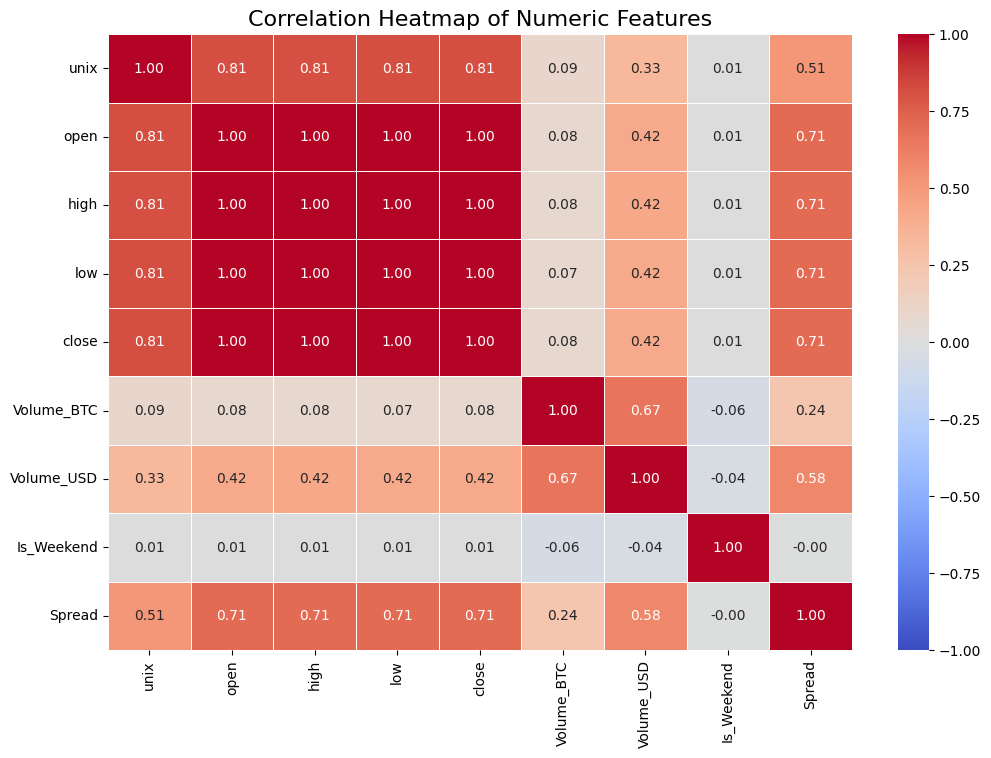

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


numeric_ds = ds.select_dtypes(include=[np.number, bool])


corr_matrix = numeric_ds.corr()

plt.figure(figsize=(12, 8))


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)


plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

/tmp/ipykernel_7510/3469110079.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_day.index, y=by_day.values, palette='viridis')


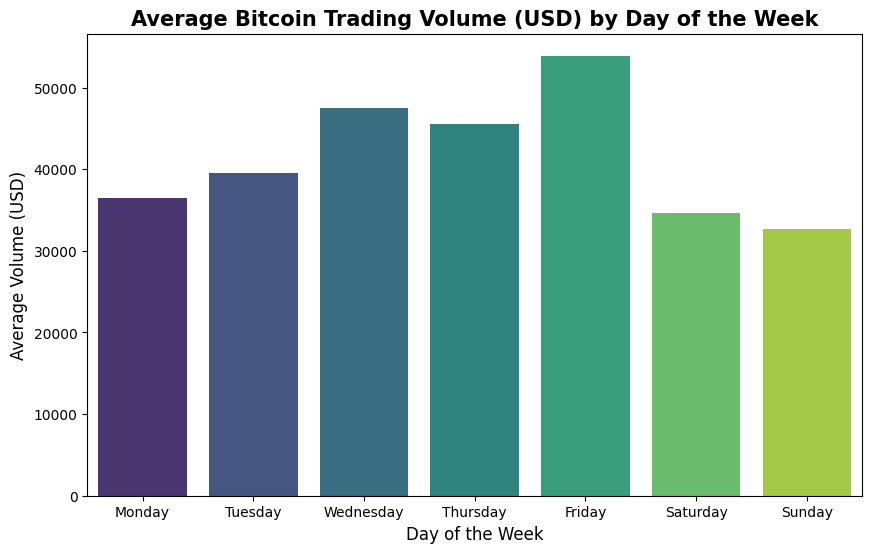

In [ ]:
by_day = ds.groupby('Day_of_Week')['Volume_USD'].mean()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

by_day = by_day.reindex(day_order)

plt.figure(figsize=(10, 6))

sns.barplot(x=by_day.index, y=by_day.values, palette='viridis')

plt.title('Average Bitcoin Trading Volume (USD) by Day of the Week', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Volume (USD)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

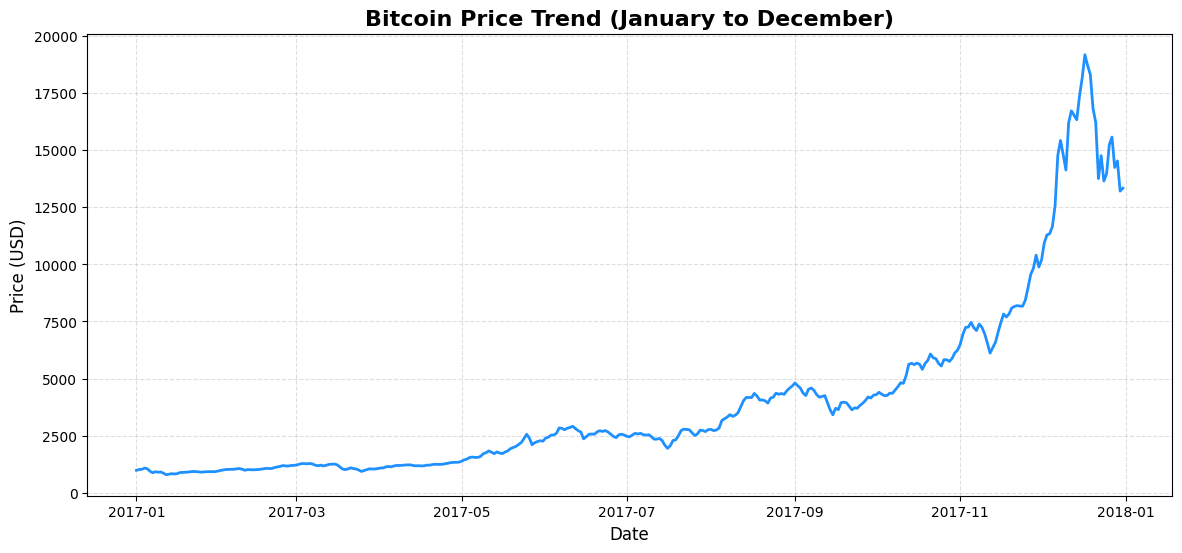

In [ ]:
plt.figure(figsize=(14, 6))
daily_price = ds['close'].resample('D').mean()

plt.plot(daily_price.index, daily_price.values, color='dodgerblue', linewidth=2)

plt.title('Bitcoin Price Trend (January to December)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

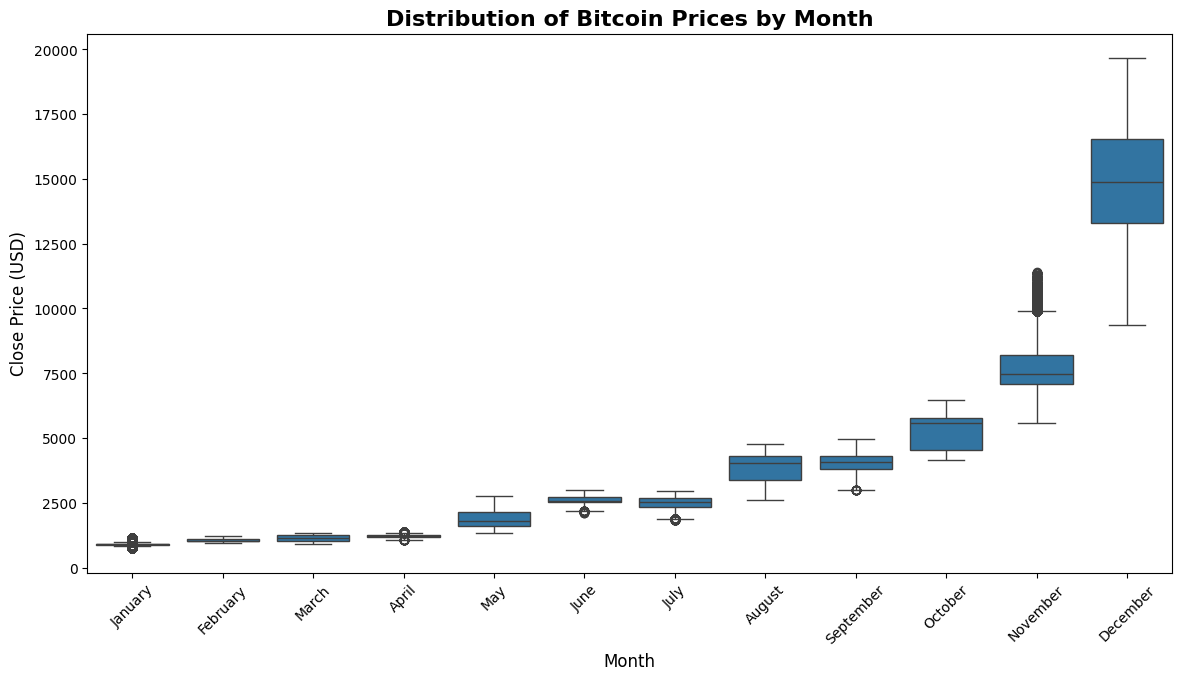

In [ ]:


plt.figure(figsize=(14, 7))


month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']


sns.boxplot(
    x='Month',
    y='close',
    data=ds,
    order=month_order)

plt.title('Distribution of Bitcoin Prices by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)


plt.xticks(rotation=45)
#AI GENERATED
plt.show()

/tmp/ipykernel_7510/1911171508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


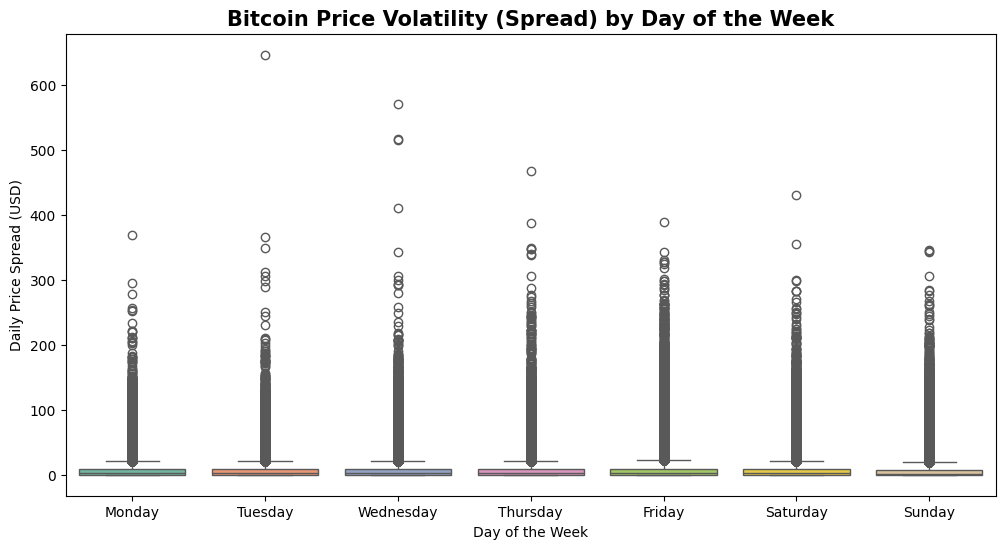

In [ ]:
plt.figure(figsize=(12, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


sns.boxplot(
    x='Day_of_Week',
    y='Spread',
    data=ds,
    order=day_order,
    palette='Set2'
)

plt.title('Bitcoin Price Volatility (Spread) by Day of the Week', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Daily Price Spread (USD)')
plt.show()

**Part C: Normalization Techniques**

**Min-Max Normalization : a)Scale the values between 0 and 1.    b)Compare original** **and normalized values**


In [ ]:
from sklearn.preprocessing import MinMaxScaler


min_max_scaler = MinMaxScaler()


ds['Volume_USD_MinMax'] = min_max_scaler.fit_transform(ds[['Volume_USD']])


print("--- Min-Max Normalization Comparison ---")
print(ds[['Volume_USD', 'Volume_USD_MinMax']].head(10))

--- Min-Max Normalization Comparison ---
                      Volume_USD  Volume_USD_MinMax
date                                               
2017-01-01 00:01:00  7353.847400           0.001429
2017-01-01 00:02:00  7815.397864           0.001519
2017-01-01 00:03:00     0.000000           0.000000
2017-01-01 00:04:00     0.000000           0.000000
2017-01-01 00:05:00   103.408010           0.000020
2017-01-01 00:06:00   320.645952           0.000062
2017-01-01 00:07:00     0.000000           0.000000
2017-01-01 00:08:00     0.000000           0.000000
2017-01-01 00:09:00     0.000000           0.000000
2017-01-01 00:10:00   672.310754           0.000131


**Z-Score Normalization (Standardization): **
**a)Transform data to have mean = 0 and standard deviation = 1.**
**b)Analyze the resulting distribution.**


In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


z_score_scaler = StandardScaler()


ds['close_ZScore'] = z_score_scaler.fit_transform(ds[['close']])


print(" Z-Score")
print(f"Mean: {ds['close_ZScore'].mean():.2f}")
print(f"Standard Deviation: {ds['close_ZScore'].std():.2f}")


# plt.figure(figsize=(10, 5))
# sns.histplot(ds['close_ZScore'], kde=True, color='purple', bins=50)

# plt.title('Distribution Analysis: Z-Score Normalized Close Price', fontsize=14, fontweight='bold')
# plt.xlabel('Z-Score (Standard Deviations from the Mean)')
# plt.ylabel('Frequency (Number of Occurrences)')


# plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Mean (0)')
# plt.legend()

# plt.show()

 Z-Score
Mean: -0.00
Standard Deviation: 1.00


**Part D: Analysis**

**Compare the outputs obtained from different normalization techniques.**


**Identify which normalization method is most suitable for the selected domain and justify your answer.**


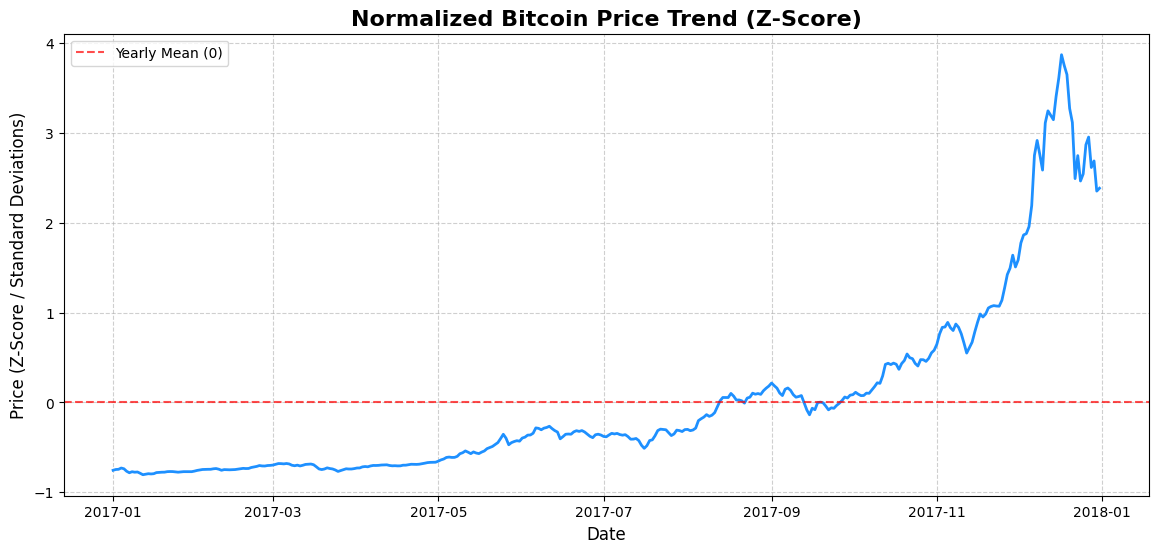

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))


daily_zscore = ds['close_ZScore'].resample('D').mean()


plt.plot(daily_zscore.index, daily_zscore.values, color='dodgerblue', linewidth=2)

plt.title('Normalized Bitcoin Price Trend (Z-Score)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (Z-Score / Standard Deviations)', fontsize=12)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Yearly Mean (0)')
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_7510/323876109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


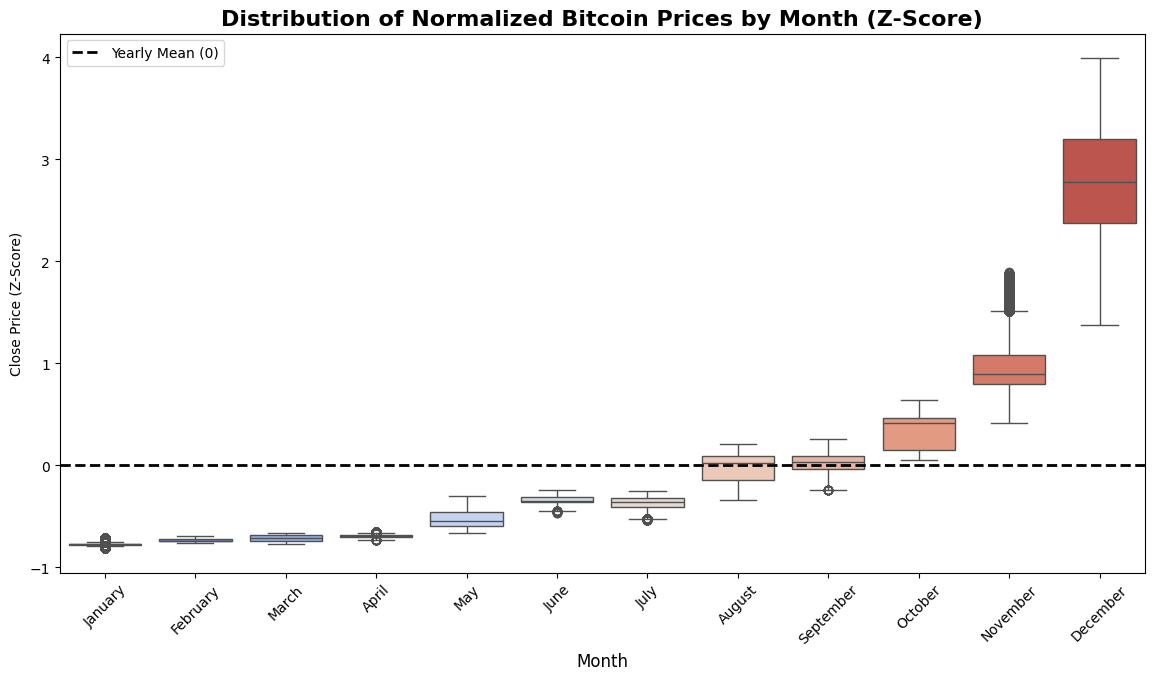

In [ ]:
plt.figure(figsize=(14, 7))

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']


sns.boxplot(
    x='Month',
    y='close_ZScore',
    data=ds,
    order=month_order,
    palette='coolwarm'
)

plt.title('Distribution of Normalized Bitcoin Prices by Month (Z-Score)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Close Price (Z-Score)')


plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Yearly Mean (0)')
plt.legend()

plt.xticks(rotation=45)
plt.show()

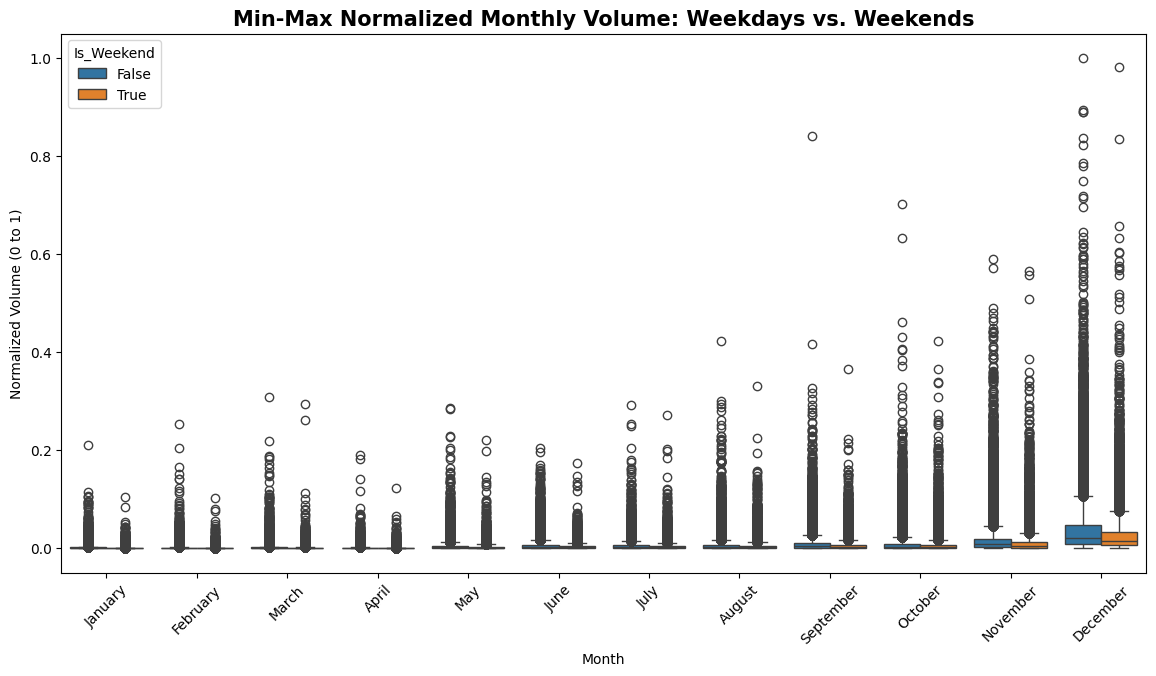

In [ ]:
plt.figure(figsize=(14, 7))


sns.boxplot(
    x='Month',
    y='Volume_USD_MinMax',
    hue='Is_Weekend',
    data=ds,
    order=month_order,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Min-Max Normalized Monthly Volume: Weekdays vs. Weekends', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Normalized Volume (0 to 1)')

plt.xticks(rotation=45)
plt.show()